In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
df = pd.read_csv(
    "C:/Users/user/OneDrive/Desktop/ZAALIMA PROJECT/CUSTOMER CHURN PREDICTION LTV ENGINE/data/processed/telco_churn_day9_processed.csv"
)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,0.013889,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.001275,No
1,5575-GNVDE,Male,0,No,No,0.472222,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,0.385075,0.215867,No
2,3668-QPYBK,Male,0,No,No,0.027778,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.010310,Yes
3,7795-CFOCW,Male,0,No,No,0.625000,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.210241,No
4,9237-HQITU,Female,0,No,No,0.027778,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.015330,Yes


In [6]:
# dataset validation
df.shape

df.columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
#create tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "New",
        "Growing",
        "Established",
        "Loyal"
    ]
)

In [8]:
#Analyze Tenure Group vs Churn
pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

Churn,No,Yes
TenureGroup,,
New,5163,1869


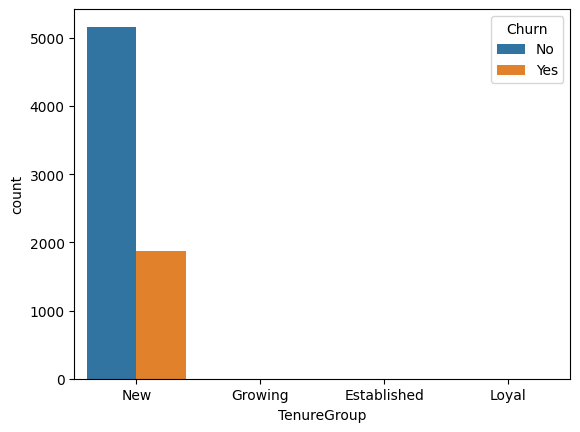

In [9]:
sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.show()

In [10]:
# Create Monthly Charge Categories
df["ChargeCategory"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

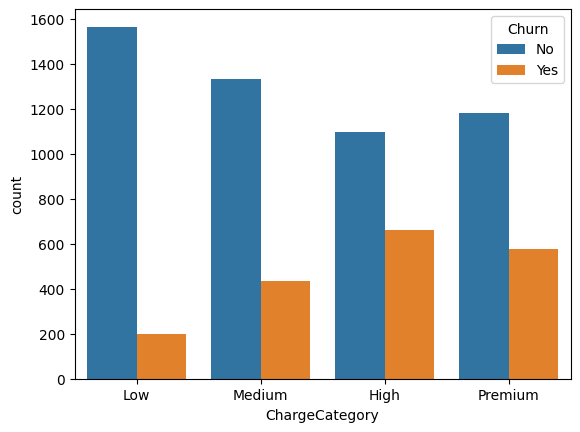

In [11]:
#Analyze Charge Category vs Churn
pd.crosstab(
    df["ChargeCategory"],
    df["Churn"]
)

sns.countplot(
    data=df,
    x="ChargeCategory",
    hue="Churn"
)

plt.show()

In [12]:
# Create Average Revenue Per Month Feature
df["RevenuePerMonth"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)


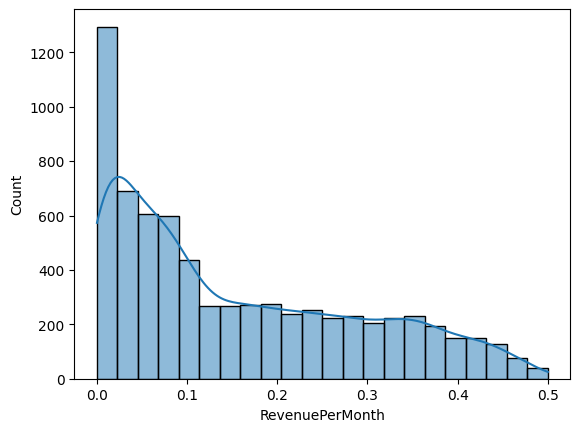

In [13]:
#explore new features
df["RevenuePerMonth"].describe()

sns.histplot(
    df["RevenuePerMonth"],
    kde=True
)

plt.show()

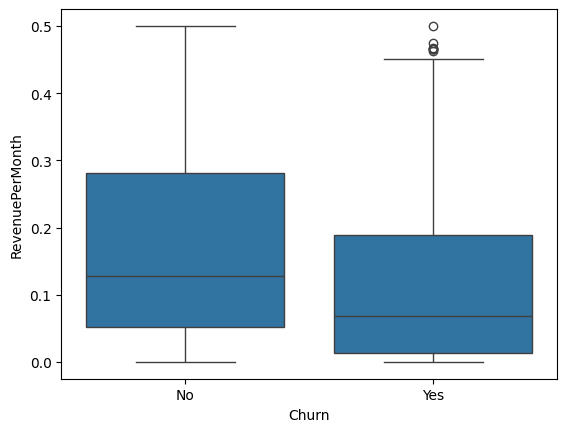

In [14]:
#Compare RevenuePerMonth vs Churn

sns.boxplot(
    data=df,
    x="Churn",
    y="RevenuePerMonth"
)

plt.show()

In [15]:
df.to_csv(
    "../../data/processed/telco_churn_day10_feature_engineered.csv",
    index=False
)